# Data

In [211]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [212]:
raw = pd.read_csv("trolly_problem_results.csv", skiprows=[0,1,3,16,17], header=0,
                  names=["A", "B", "GPT4_inact", "GPT4_pull", "Gemini2_inact", "Gemini2_pull",
                         "DeepseekV3_inact", "DeepseekV3_pull", "Perplexity_inact", "Perplexity_pull", "Grok_inact", "Grok_pull"],
                  usecols=[1,2,3,4,7,8,9,10,11,12,13,14]
                  ).reindex(range(12))

In [213]:
models = ["GPT4", "Gemini2", "DeepseekV3", "Perplexity", "Grok"]
actions = ["inact", "pull"]
scenarios = list(range(12))

model_names = ["ChatGPT 4", "Gemini 2", "Deepseek V3", "Perplexity", "Grok"]

In [214]:
df = pd.DataFrame({
    f"{s}_{a}" : [raw[f"{m}_{a}"][s] for m in models] for s in scenarios for a in actions
}, index=models)

for s in scenarios:
    df[f"{s}_win"] = [max(df[f"{s}_inact"][m], df[f"{s}_pull"][m]) for m in models]

df["total_inact"] = [np.sum([df[f"{s}_inact"][m] for s in scenarios]) for m in models]
df["total_pull"] = [np.sum([df[f"{s}_pull"][m] for s in scenarios]) for m in models]
df["avg_win"] = [np.average([df[f"{s}_win"][m] for s in scenarios]) for m in models]
df["std_win"] = [np.std([df[f"{s}_win"][m] for s in scenarios]) for m in models]

# Visualize

## Decision

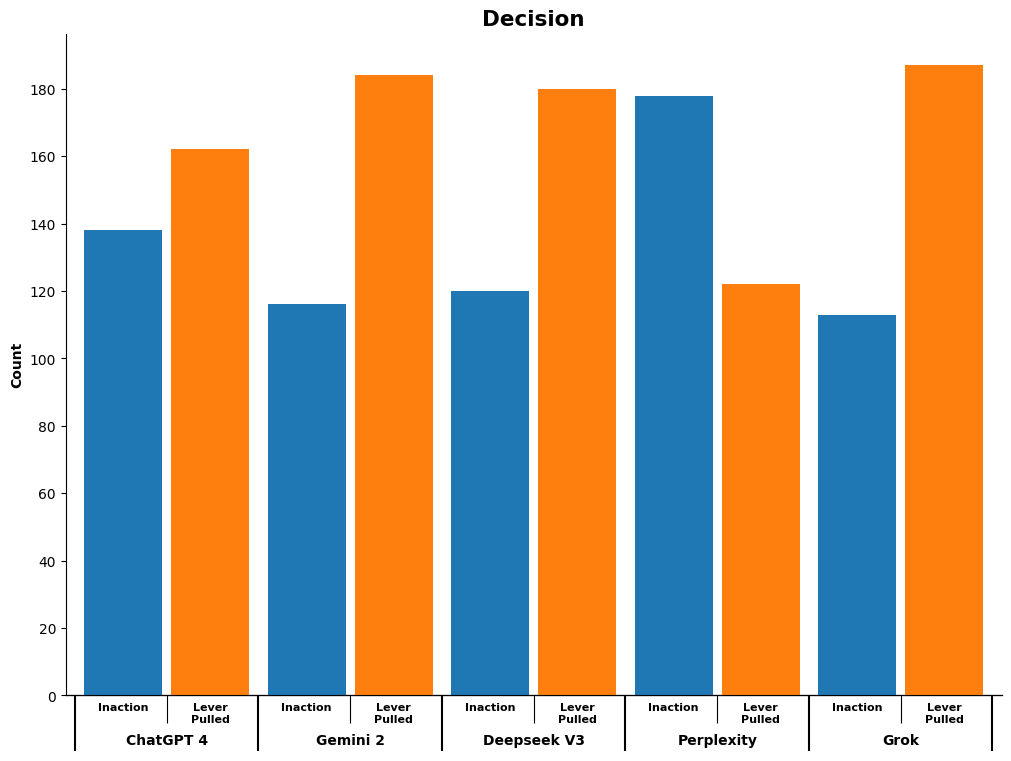

In [157]:
# figure
fig = plt.figure(figsize=(10, 7.5), layout="constrained")
ax = fig.gca()
mod = ax.secondary_xaxis(location=-0.05)
div1 = ax.secondary_xaxis(location=0)
div2 = ax.secondary_xaxis(location=0)

# specifications
p = 0.05
w = (1 - (3*p)) / 2
o = (w+p)/2

# values
x = np.linspace(0, 4, 5)
y1 = df["total_inact"].values
y2 = df["total_pull"].values

# bars
ax.bar(x=x-o, height=y1, width=w, color="tab:blue")
ax.bar(x=x+o, height=y2, width=w, color="tab:orange")

# labels
ax.set_title("Decision", weight="bold", size=15.5)
ax.set_xticks(ticks=[xv+off for xv in x for off in [-o, o]],
              labels=[a for _ in models for a in ["Inaction", "Lever\nPulled"]], weight="bold", size=8)
mod.set_xticks(ticks=x, labels=model_names, weight="bold", size=10)
ax.set_ylabel("Count", weight="bold")

# axis specifications
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
mod.spines["bottom"].set_visible(False)

ax.tick_params("x", length=0, pad=5)
mod.tick_params("x", length=0)

div1.set_xticks(ticks=np.linspace(-0.5, 4.5, 6), labels=[])
div1.tick_params("x", length=40, width=1.5)

div2.set_xticks(ticks=x, labels=[])
div2.tick_params("x", length=20)

# y-ticks
ax.set_yticks(ticks=np.linspace(0, 180, 10))

# axis limits
l = 0 - (w + (2*p) + (p/2))
r = 4 + (w + (2*p) + (p/2))
ax.set_xlim(left=l, right=r)

# save
fig.savefig("figures/decision.svg", transparent=True)

## Consistency

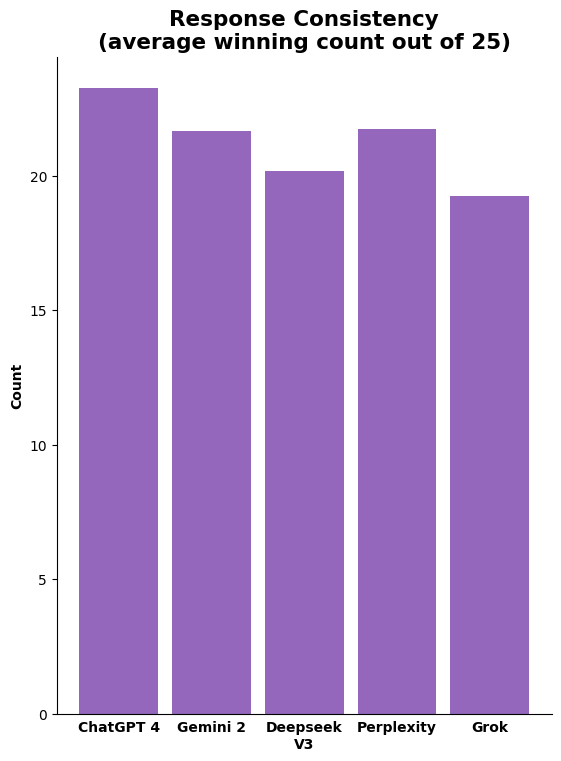

In [165]:
# figure
fig = plt.figure(figsize=(5.5, 7.5), layout="constrained")
ax = fig.gca()

# specifications
p = 0.075
w = 1 - (2*p)

# values
x = np.linspace(0, 4, 5)
y = df["avg_win"].values
e = df["std_win"].values

# bar
ax.bar(x=x, height=y, width=w, color="tab:purple")
# ax.errorbar(x=x, y=y, yerr=e, color="black", ls="none", capsize=5)

# labels
ax.set_title("Response Consistency\n(average winning count out of 25)", weight="bold", size=15.5)
ax.set_xticks(ticks=x, labels=["ChatGPT 4", "Gemini 2", "Deepseek\nV3", "Perplexity", "Grok"], weight="bold", size=10)
ax.set_ylabel("Count", weight="bold")

# axis specifications
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_yticks(ticks=np.linspace(0, 20, 5))
ax.tick_params("x", length=0, pad=5)

# save
fig.savefig("figures/consistency.svg", transparent=True)

## Scenarios

In [ ]:
inact = [sum([raw[f"{m}_inact"][s] for m in models]) for s in scenarios]
pull = [sum([raw[f"{m}_pull"][s] for m in models]) for s in scenarios]

def add_newline(s:str, pos:int) -> str:
    spl = s.split(" ")
    return " ".join(spl[:pos]) + "\n" + " ".join(spl[pos:])

nlpos = [0, 3, 3, 3, 3, 3,
         4, 3, 3, 3, 3, 3]
titles = [add_newline(f"{a} vs. {b}", p) for a,b,p in zip(raw["A"].values, raw["B"].values, nlpos)]
labels = 
sizes = [(i,p) for i,p in zip(inact, pull)]

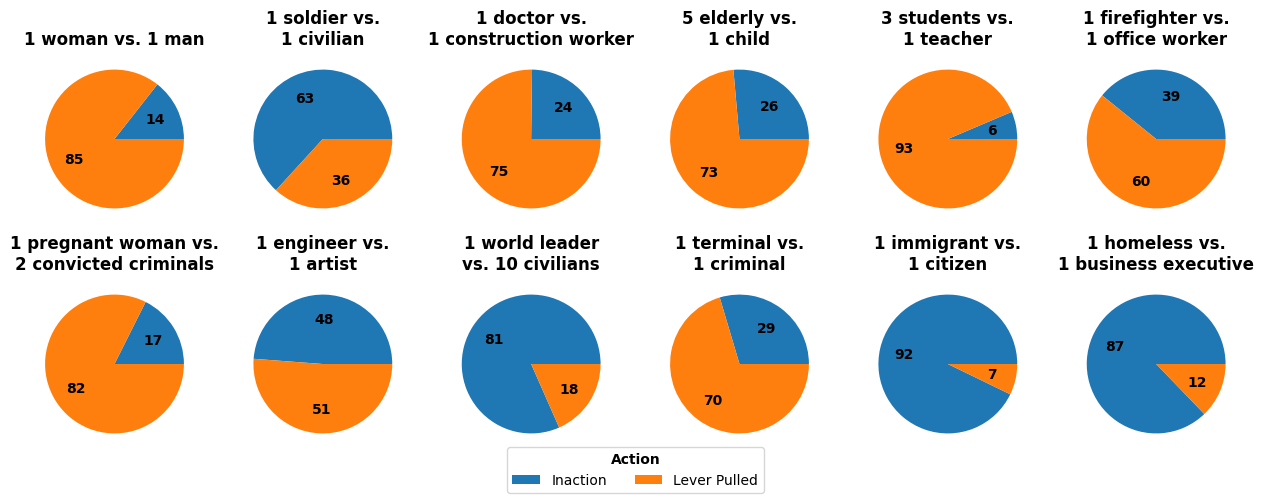

In [210]:
# figure
fig,ax = plt.subplots(nrows=2, ncols=6, figsize=(12.5, 4.5), layout="constrained")

# plot
p = [ax[i][j].pie(x=sizes[(i*6)+j], autopct="%d", pctdistance=0.65, textprops={"weight":"bold"})[0] for i in range(2) for j in range(6)]

# labels
[ax[i][j].set_title(titles[(i*6)+j], weight="bold") for i in range(2) for j in range(6)]

# legend        
fig.legend(handles=p[0], labels=["Inaction", "Lever Pulled"], ncols=2,
           title="Action", title_fontproperties={"weight":"bold"},
           loc=8, bbox_to_anchor=(0.5, -0.1))

# save
fig.savefig("figures/scenarios.svg", transparent=True, bbox_inches="tight")